<h2>Loading Data for Recommendation Modelling</h2>

<p>
To build the recommendation engine, the cleaned data is loaded from the SQLite database into pandas DataFrames.
</p>

<ul>
  <li><strong>Profiles:</strong> all profile details including preferences.</li>
  <li><strong>Titles:</strong> all show information such as category, language, age rating, and popularity metrics.</li>
</ul>

<p>
A <strong>parse_preferences</strong> function is applied to convert the preferences column into a list format.  
This makes it easier to match user preferences with title categories during recommendation calculations.
</p>

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import math

conn = sqlite3.connect("../streamly.db")

profiles = pd.read_sql_query("SELECT * FROM profiles;", conn)
titles = pd.read_sql_query("SELECT * FROM titles;", conn)

conn.close()

def parse_preferences(pref_str):
    if pref_str is None or str(pref_str).strip() == "":
        return []
    
profiles["preference_list"] = profiles["preferences"].apply(parse_preferences)

<h2>Scoring Helpers for Recommendations</h2>

<p>
To calculate recommendation scores, two helper functions are defined:
</p>

<h3>1. Age Suitability</h3>
<p>
The <strong>allowed_ratings_for_age_band</strong> function returns a list of acceptable age ratings based on the profile's age band:
</p>
<ul>
  <li>Under 13 → "G" and "PG"</li>
  <li>13–17 → "G", "PG", "13+"</li>
  <li>18+ → all ratings including "16+" and "18+"</li>
</ul>
<p>
This ensures that recommended titles are appropriate for the user’s age.
</p>

<h3>2. Popularity Score</h3>
<p>
The <strong>popularity_score</strong> function calculates a simple heuristic to measure a title’s popularity.  
It combines the IMDB rating and vote count to give higher scores to well-rated and widely watched titles.
</p>

In [2]:
# define scoring helpers
# age suitability def

def allowed_ratings_for_age_band(age_band: str):
    age_band = str(age_band)

    if age_band == "<13":
        return ["G", "PG"]
    elif age_band == "13-17":
        return ["G", "PG", "13+"]
    else:
        return ["G","PG", "13+", "16+", "18+"]
    
def popularity_score(row):
    # normalise imdb_rating (0-10) and votes
    rating = row.get("imdb_rating", 0) or 0
    votes = row.get("imdb_votes", 0) or 0
    return rating * 2 + math.log1p(votes) # simple heuristic


<h2>Core Recommendation Function</h2>

<p>
The function generates personalized title recommendations for a given profile. It calculates a score for each title based on multiple factors, then returns the top N titles.
</p>

<h3>Steps in the Function</h3>

<ul>
  <li><strong>Fetch Profile:</strong> Retrieve the profile by <code>profile_id</code>. If the profile does not exist, return an empty list.</li>
  
  <li><strong>Prepare Profile Preferences:</strong> Extract age band, kids profile flag, preferred language, and preferred genres. Missing preferences are handled safely.</li>
  
  <li><strong>Allowed Age Ratings:</strong> Determine which title age ratings are suitable for this profile using the age suitability helper.</li>
  
  <li><strong>Score Each Title:</strong> Iterate over all titles and calculate a score based on:
    <ul>
      <li>Age/content suitability (+40 if suitable, -20 if not)</li>
      <li>Kids vs non-kids content (bonus for matching, penalty for mismatching)</li>
      <li>Language match (+30 if matches)</li>
      <li>Genre/preferences match (+25 if there is overlap)</li>
      <li>Popularity (adds the popularity score)</li>
    </ul>
  </li>
  
  <li><strong>Sort and Select Top Titles:</strong> Sort titles by the total score in descending order and select the top N recommendations.</li>
  
  <li><strong>Return Structured Results:</strong> Provide a clean list of recommended titles including ID, name, category, age rating, language, and score.</li>
</ul>

<p>
This scoring system balances content suitability, user preferences, and title popularity to produce personalized recommendations.
</p>

In [3]:
# core recommendatoin function

def recommend_titles_for_profile(profile_id: int, n: int = 10):
    # fetch profile

    prof = profiles.loc[profiles["profile_id"] == profile_id]
    if prof.empty:
        return []
    
    prof = prof.iloc[0]
    age_band = prof["age_band"]
    kids_profile = bool(prof["kids_profile"])
    pref_lang = prof["preferred_language"]
    # safely handle missing preference_list
    raw_pref = prof.get("preference_list")

    if raw_pref is None or raw_pref == "":
        pref_genres = set()
    else:
    # convert "Action, Comedy" to {"action", "comedy"}
        pref_genres = set([p.strip().lower() for p in raw_pref.split(",")])

    allowed_ratings = allowed_ratings_for_age_band(age_band)

    df = titles.copy()

    scores = []

    for _, row in df.iterrows():
        score = 0

        # age / content suitability
        if row["age_rating"] in allowed_ratings:
            score += 40
        else: 
            score -= 20
        
        # kids vs non-kids content

        is_kids_title = bool(row["is_kids_content"])
        if kids_profile:
            if is_kids_title:
                score += 30
            else: 
                score -= 100 # hard penalty
        else: 
            if is_kids_title:
                score -= 5 # deprioritise kids for adult profiles
            
        # language match
        if str(row["language"]).lower() == str(pref_lang).lower():
            score += 30

        # Genre / preference match

        cat = str(row["category"]).lower()
        subcat = str(row["sub_category"]).lower()
        title_genres = {cat, subcat}
        if pref_genres & title_genres:
            score += 25

        # Popularity
        score += popularity_score(row)

        scores.append(score)

    df["score"] = scores
    df_sorted = df.sort_values("score", ascending=False).head(n)

    # return structured list

    results = df_sorted[["show_id", "title_name", "category", "age_rating", "language", "score"]]
    return results.to_dict(orient="records")

<h2>Generating Recommendations for a Sample Profile</h2>

<p>
To test the recommendation engine, a random profile is selected from the profiles table.  
The top 10 recommended titles are then generated for this profile using the core recommendation function.
</p>

<ul>
  <li><strong>Sample Profile:</strong> One profile is randomly selected from the dataset.</li>
  <li><strong>Generate Recommendations:</strong> The recommendation function calculates scores for all titles and returns the top 10 matches.</li>
  <li><strong>Result:</strong> A structured list showing recommended titles, their category, age rating, language, and calculated score.</li>
</ul>

<p>
This step demonstrates how the engine works in practice and can be repeated for any profile.
</p>

In [ ]:
sample_profile_id = int(profiles["profile_id"].sample(1).iloc[0])
sample_profile_id

recs = recommend_titles_for_profile(sample_profile_id, n=10)
recs

[{'show_id': 'tt0317705',
  'title_name': 'The Incredibles',
  'category': 'Action',
  'age_rating': '18+',
  'language': 'en',
  'score': 69.71879038458604},
 {'show_id': 'tt0247882',
  'title_name': 'Forensic Files',
  'category': 'Crime',
  'age_rating': '18+',
  'language': 'en',
  'score': 66.58919482332465},
 {'show_id': 'tt0376994',
  'title_name': 'X-Men: The Last Stand',
  'category': 'Action',
  'age_rating': '18+',
  'language': 'en',
  'score': 66.44752004974916},
 {'show_id': 'tt33472422',
  'title_name': 'Informant',
  'category': 'Action',
  'age_rating': '16+',
  'language': None,
  'score': 64.81442397564837},
 {'show_id': 'tt7060750',
  'title_name': 'Daybreak',
  'category': 'Drama',
  'age_rating': '16+',
  'language': 'cmn',
  'score': 64.80545621140273},
 {'show_id': 'tt33342932',
  'title_name': 'Ma que gou',
  'category': 'Drama',
  'age_rating': '13+',
  'language': 'cmn',
  'score': 64.73837298215959},
 {'show_id': 'tt27611340',
  'title_name': 'Bachhala Malli

In [9]:
import pandas as pd 

profile_id = int(profiles["profile_id"].sample(1).iloc[0])
recs = recommend_titles_for_profile(sample_profile_id, n=10)

recs_df = pd.DataFrame(recs)
recs_df


,show_id,title_name,category,age_rating,language,score
0,tt0317705,The Incredibles,Action,18+,en,69.718790
1,tt0247882,Forensic Files,Crime,18+,en,66.589195
2,tt0376994,X-Men: The Last Stand,Action,18+,en,66.447520
3,tt33472422,Informant,Action,16+,None,64.814424
4,tt7060750,Daybreak,Drama,16+,cmn,64.805456
5,tt33342932,Ma que gou,Drama,13+,cmn,64.738373
6,tt27611340,Bachhala Malli,Action,16+,en,64.699037
7,tt0312513,Counting Stars,Crime,16+,en,64.672646
8,tt11214122,When Shui Met Mo: A Love Story,Drama,16+,None,64.650057
9,tt11615290,Beastie Boys Story,Biography,16+,cmn,64.465546


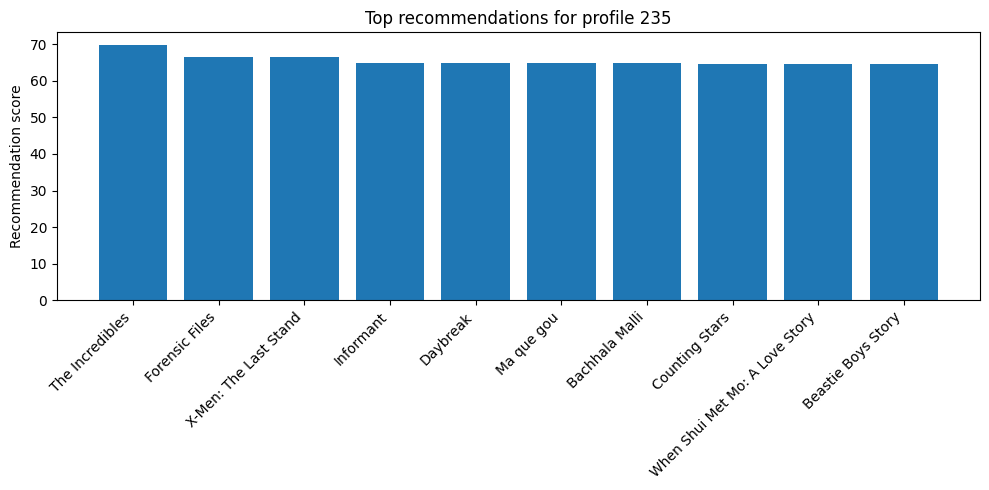

In [10]:
import matplotlib.pyplot as plt

recs_df = recs_df.sort_values("score", ascending=False)

plt.figure(figsize=(10,5))

plt.bar(recs_df["title_name"], recs_df["score"])
plt.xticks(rotation=45, ha = "right")
plt.ylabel("Recommendation score")
plt.title(f"Top recommendations for profile {profile_id}")

plt.tight_layout()
plt.show()

/var/folders/19/f_xs14297yd5j_6z53jymh7m0000gn/T/ipykernel_17594/3617121746.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(kids_recs["title_name"], rotation=45, ha="right")
/var/folders/19/f_xs14297yd5j_6z53jymh7m0000gn/T/ipykernel_17594/3617121746.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(adult_recs["title_name"], rotation=45, ha="right")


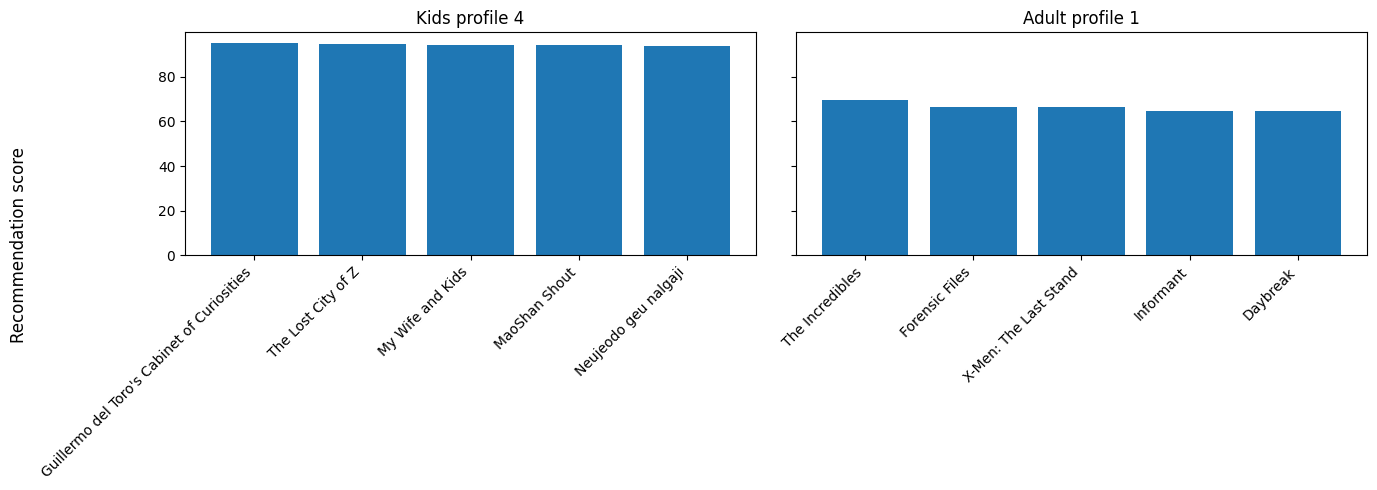

In [13]:
# pick one kids profile and one adult profile, for example

kids_profile = profiles[profiles["kids_profile"] == 1]["profile_id"].iloc[0]

adult_profile = profiles[profiles["kids_profile"] == 0]["profile_id"].iloc[0]

 

kids_recs = pd.DataFrame(recommend_titles_for_profile(kids_profile, n=5))

adult_recs = pd.DataFrame(recommend_titles_for_profile(adult_profile, n=5))

kids_profile, adult_profile


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

 

# Kids

kids_recs = kids_recs.sort_values("score", ascending=False)

axes[0].bar(kids_recs["title_name"], kids_recs["score"])

axes[0].set_title(f"Kids profile {kids_profile}")

axes[0].set_xticklabels(kids_recs["title_name"], rotation=45, ha="right")

 

# Adult

adult_recs = adult_recs.sort_values("score", ascending=False)

axes[1].bar(adult_recs["title_name"], adult_recs["score"])

axes[1].set_title(f"Adult profile {adult_profile}")

axes[1].set_xticklabels(adult_recs["title_name"], rotation=45, ha="right")

 

fig.supylabel("Recommendation score")

fig.tight_layout()

plt.show()

 

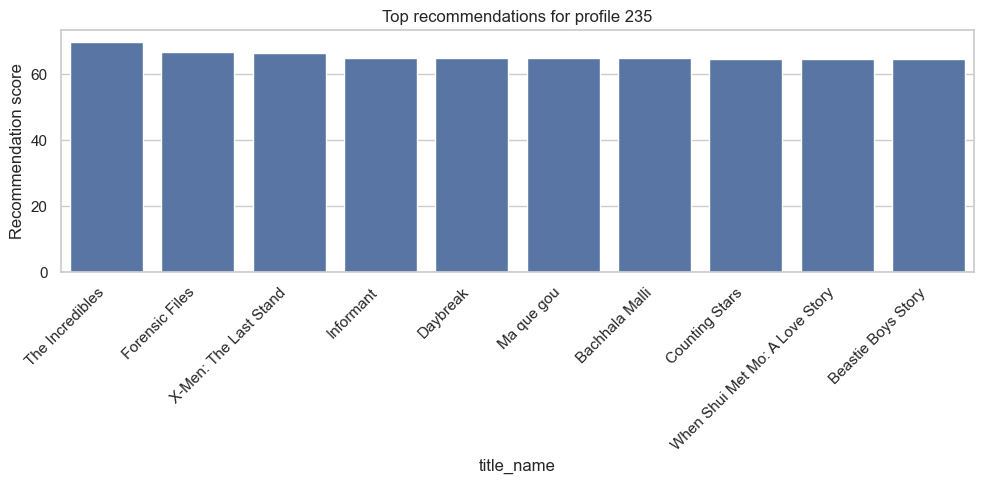

In [14]:
import seaborn as sns

import matplotlib.pyplot as plt

 

sns.set(style="whitegrid")

 

plt.figure(figsize=(10, 5))

sns.barplot(data=recs_df, x="title_name", y="score")

plt.xticks(rotation=45, ha="right")

plt.ylabel("Recommendation score")

plt.title(f"Top recommendations for profile {profile_id}")

plt.tight_layout()

plt.show()

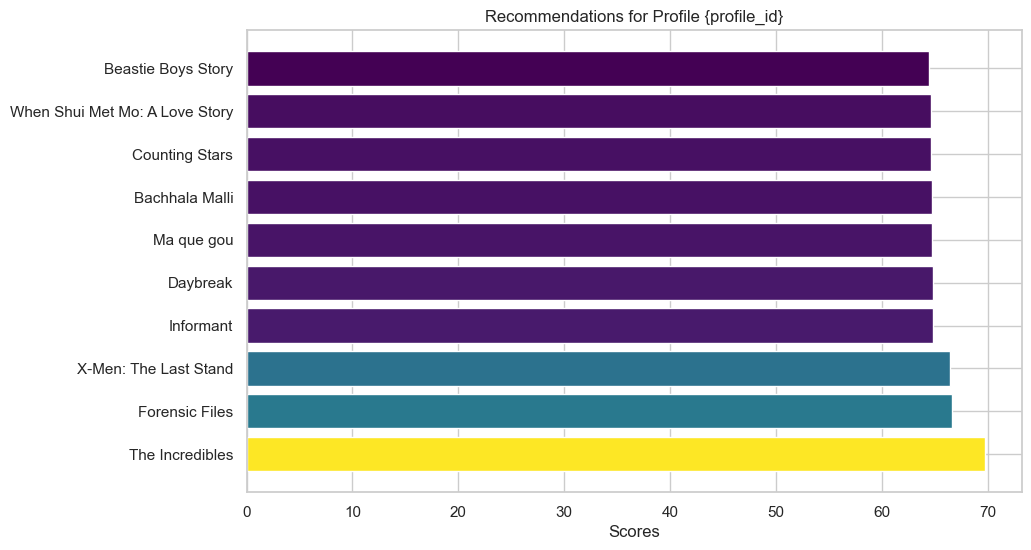

In [20]:
plt.figure(figsize=(10, 6))

scores = recs_df["score"]
colors = plt.cm.viridis((scores - scores.min()) / (scores.max() - scores.min()))

plt.barh(recs_df["title_name"], scores, color = colors)
plt.xlabel("Scores")
profile_id = int(profiles["profile_id"].sample(1).iloc[0])
plt.title("Recommendations for Profile {profile_id}")
plt.gca().invert_yaxis
plt.show()

<h2>Recommendation Engine Design and Future Extensions</h2>

<h3>Input Features Used</h3>
<ul>
  <li><strong>Profile Features:</strong> age band, kids profile flag, preferred language, and preferred genres.</li>
  <li><strong>Title Features:</strong> age rating, kids content flag, language, category and sub-category, IMDB rating, number of votes.</li>
</ul>

<h3>Scoring Logic</h3>
<ul>
  <li><strong>Age and content suitability:</strong> Titles appropriate for the profile’s age band are rewarded; inappropriate ones are penalized.</li>
  <li><strong>Kids vs non-kids content:</strong> Kids profiles are strongly matched with kids content; adult profiles are slightly penalized for kids content.</li>
  <li><strong>Language match:</strong> Titles in the profile’s preferred language receive a score boost.</li>
  <li><strong>Genre preference:</strong> Titles that match any of the profile’s preferred genres are scored higher.</li>
  <li><strong>Popularity:</strong> Combines IMDB rating and number of votes to favor widely liked and watched titles.</li>
</ul>

<h3>How to Extend with Real Viewing History</h3>
<p>
Currently, the recommendations are based on profile metadata and general title popularity.  
In the future, incorporating real viewing history would allow for personalized recommendations based on past behavior, for example:
</p>
<ul>
  <li>Weighting genres and categories according to what the user has watched most.</li>
  <li>Tracking which titles were completed, skipped, or rewatched to adjust relevance scores.</li>
  <li>Including temporal patterns, such as recently watched content, for trending recommendations.</li>
  <li>Using collaborative filtering techniques to suggest titles popular among users with similar viewing habits.</li>
</ul>

<p>
Integrating viewing history would make the engine dynamic, more accurate, and tailored to individual preferences over time.
</p>